# RAPID2 Tutorial

This tutorial provides an example of how to integrate RAPID2 into a workflow using `Python` to handle model setup and examination of model output. The code below allows for the selection of several model parameters at the start, such as basin, simulation date, and input runoff model, and then perofmrs model setup automatically. Several python packages are used in this tutorial, but all are included in the RAPID2 pypi package except for Matplotlib, which is a commonly used Python plotting package. 

First, ensure that the Python package for RAPID2 is installed.

> ⚠️ UNDER CONSTRUCTION

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/c-h-david/rapid-hub/anyBasinTutorial?labpath=docs/user-guide/examples/tutorial-anyBasin.ipynb)

In [1]:
%%bash
rapid2 --version && echo "[OK] - rapid2 is installed."

rapid2 2.0.0b3
[OK] - rapid2 is installed.


Next, import Python packages needed for the tutorial.

In [13]:
import os
import zipfile
from pathlib import Path
import urllib.request
import yaml
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import getpass

## 1. Set Parameters
Here is where we set the parameters for the run:
- *BASIN*: Set the basin ID based on global Pfafstetter Level 2 hydrologic regions (e.g. pfaf_74 for the Mississippi Basin)
- *PHASE*: Phase of GLDAS forcing to use (e.g. 2.1)
- *MODEL*: The hydrologic model to use for input (options are: VIC, CLSM, NOAH)
- *TIME*: The year and month for the simulation (e.g.'2010-01')

Note that all input paramaters must be provided as strings.

In [3]:
BASIN = "pfaf_31"
WORK_DIR = Path("rapid2_tutorial")
INPUT_DIR = WORK_DIR / "input"
OUTPUT_DIR = WORK_DIR / "output"
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Donwload Static River Parameters

### Required Input Files
##### River Network Files (CSV format)

- **Connectivity file (con_csv):** Defines river network topology with upstream/downstream relationships
- **Basin IDs file (bas_csv):** Specifies which river reaches are included in the simulation
- **Parameter files (kpr_csv, xpr_csv):** Muskingum routing parameters for each river reach

##### Hydrological Data (NetCDF4 format)

- **External inflow (Qex_ncf):** Lateral inflow from land surface models
- **Initial conditions (Q00_ncf):** Starting discharge values for all river reaches

### Output Files
#### RAPID produces the following outputs:

- **Discharge time series (Qou_ncf):** Routed discharge for all time steps
- **Final state (Qfi_ncf):** Final discharge values for model restart



In [10]:
ZENODO_RECORD = "20672740"
ZENODO_BASE = f"https://zenodo.org/records/{ZENODO_RECORD}/files"

print(f"Downloading {BASIN} ZIP file from Zenodo record {ZENODO_RECORD}...")
url = f"{ZENODO_BASE}/MERIT_Basins_v1.0_{BASIN}_GLDAS_v2.0_RAPID_v2.0.zip?download=1"
dest = INPUT_DIR / BASIN 
if not dest.exists():
    urllib.request.urlretrieve(url, dest)
else:
    print(f'\tFiles already downloaded')
with zipfile.ZipFile(dest, "r") as z:
        z.extractall(INPUT_DIR)
print(f"\nStatic files for {BASIN}:")
for f in sorted(INPUT_DIR.glob(f"*{BASIN}*")):
    print(f"  {f.name}")

	Files already downloaded

Static files for pfaf_31:
  bas_pfaf_31_topo.parquet
  con_pfaf_31.parquet
  cpl_pfaf_31_GLDAS.parquet
  crd_pfaf_31.parquet
  kpr_pfaf_31_nrm.parquet
  pfaf_31
  xpr_pfaf_31_nrm.parquet


## 3. Downlod NLDAS Runoff Data

**To Do:** 
- Add description and options for download cli inputs/outputs

In [11]:
PHASE = '2.1'
MODEL = 'VIC'
TIME = '2010-01'
GLDAS_FILE = INPUT_DIR / f'GLDAS_2.1_VIC_{TIME}.nc4'
print(GLDAS_FILE)

rapid2_tutorial/input/GLDAS_2.1_VIC_2010-01.nc4


In [ ]:
# Held in an environment variable, which the %%bash cells below inherit so that
# dgldas2 can authenticate.
os.environ["EARTHDATA_TOKEN"] = getpass.getpass("Earthdata token: ").strip()

if not os.environ["EARTHDATA_TOKEN"]:
    raise RuntimeError(
        "[ERROR] No token entered. Generate one at https://urs.earthdata.nasa.gov "
        "under 'Generate Token', then re-run this cell."
    )

auth = earthaccess.login(strategy="environment")

if not auth.authenticated:
    raise RuntimeError("[ERROR] Earthdata login failed - re-run this cell.")

print("[OK] - Earthdata token registered for this session.")

In [12]:
!dgldas2 \
    --phase {PHASE} \
    --model {MODEL} \
    --time {TIME} \
    --land_surface_model \
    {GLDAS_FILE}

Download data from GLDAS2.1 for VIC and 2010-01 as rapid2_tutorial/input/GLDAS_2.1_VIC_2010-01.nc4
- Login
- Search GLDAS_VIC10_3H 2.1 2010-01 max=300
/Users/mbonnema/miniconda3/envs/rapid2/lib/python3.14/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
- Download 248 files
/Users/mbonnema/miniconda3/envs/rapid2/lib/python3.14/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)
- Check files
- Concatenate file
- Convert accumulated depth to depth rate
  . Dividing accumulations by IS_dtE: 10800.0 seconds
- Delete files


## 4. Transform Runoff

**To Do:**
- Add description of cpllsm cli command

In [14]:
QEXT_FILE = INPUT_DIR / f"Qext_{BASIN}_GLDAS_2.1_VIC_2010-01.nc4"

!cpllsm \
    --land_surface_model \
    {GLDAS_FILE} \
    --connectivity \
    {INPUT_DIR}/con_{BASIN}.parquet \
    --coordinates \
    {INPUT_DIR}/crd_{BASIN}.parquet \
    --coupling \
    {INPUT_DIR}/cpl_{BASIN}_GLDAS.parquet \
    --external_inflow \
    {QEXT_FILE}

Transforming data from  rapid2_tutorial/input/GLDAS_2.1_VIC_2010-01.nc4 for rapid2_tutorial/input/con_pfaf_31.parquet with rapid2_tutorial/input/crd_pfaf_31.parquet and rapid2_tutorial/input/cpl_pfaf_31_GLDAS.parquet as rapid2_tutorial/input/Qext_pfaf_31_GLDAS_2.1_VIC_2010-01.nc4
- Read connectivity file
  . The number of river reaches in connectivity file is: 81405
- Read coordinate file
  . The river reaches are the same as in connectivity file
- Read coupling file
  . The river reaches are the same as in connectivity file
- Check consisitency of coupling file
 . OK
- Read LSM metadata
  . The number of longitudes is: 360
  . The number of latitudes is: 150
  . The number of time steps is: 248
  . The fill value for Qs_acc is: -9999.0
  . The fill value for Qsb_acc is: -9999.0
- Create Qext file
- Populate dynamic data
Processing LSM data: 100%|███████████████████| 248/248 [00:00<00:00, 603.18it/s]


## 5. Generate Cold Start

**To Do:** 
- Add description of zeroqinit cli command

In [15]:
QINIT_FILE = INPUT_DIR / f"Qinit_{BASIN}_GLDAS_2.1_VIC_2010-01.nc4"

!zeroqinit \
    --external_inflow \
    {QEXT_FILE} \
    --initial_outflow \
    {QINIT_FILE}

Creating (from/to):
 - rapid2_tutorial/input/Qext_pfaf_31_GLDAS_2.1_VIC_2010-01.nc4
 - rapid2_tutorial/input/Qinit_pfaf_31_GLDAS_2.1_VIC_2010-01.nc4


## 6. Make Namelist File and Run Rapid2

**To Do:**
- Add description of namelist file format

In [21]:
NL = {
    'Qex_ncf': f'./{QEXT_FILE}',
    'Q00_ncf': f'./{QINIT_FILE}',

    'con_pqt': f'./{INPUT_DIR}/con_{BASIN}.parquet' ,
    'kpr_pqt': f'./{INPUT_DIR}/kpr_{BASIN}_nrm.parquet',
    'xpr_pqt': f'./{INPUT_DIR}/xpr_{BASIN}_nrm.parquet',

    'bas_pqt': f'./{INPUT_DIR}/bas_{BASIN}_topo.parquet',

    'IS_dtR': 900,

    'Qou_ncf': f'./{OUTPUT_DIR}/Qout_{BASIN}_GLDAS_{PHASE}_{MODEL}_{TIME}_tst.nc4',
    'Qfi_ncf': f'./{OUTPUT_DIR}/Qfinal_{BASIN}_GLDAS_{PHASE}_{MODEL}_{TIME}_tst.nc4'
}

with open(f'{INPUT_DIR}/name_list.yml', 'w') as yaml_file:
    yaml.dump(NL,yaml_file,default_flow_style=False)

In [23]:
!rapid2 --namelist {INPUT_DIR}/name_list.yml

Namelist file: rapid2_tutorial/input/name_list.yml
Computing discharge: 100%|████████████████████| 248/248 [00:05<00:00, 43.35it/s]
Done


## 7. Plot Output

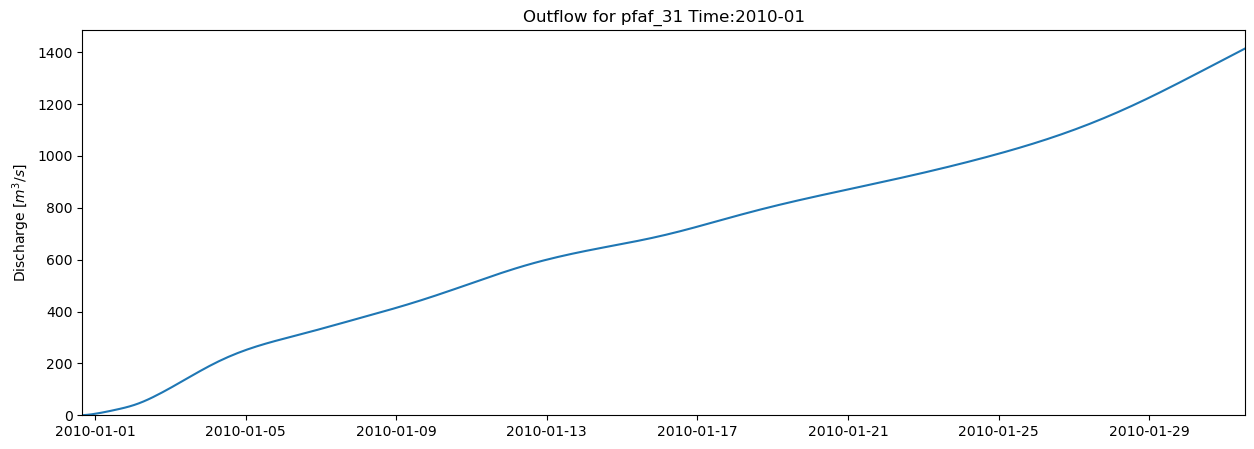

In [20]:
with netCDF4.Dataset(f'./{OUTPUT_DIR}/Qout_{BASIN}_GLDAS_{PHASE}_{MODEL}_{TIME}_tst.nc4','r') as ds:
    qout = ds.variables["Qout"][:]
    rivid = ds.variables["rivid"][:]
    time = ds.variables['time'][:]
    date = []
    #print(ds.variables)
    for t in time:
        date.append(datetime.fromtimestamp(t))

    mean_per_reach = np.mean(qout, axis=0)
    main = int(np.argmax(mean_per_reach))
    peak_q=float(np.max(qout[:, main]))

    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_ylim(0,peak_q*1.05)
    ax.set_xlim(date[0],date[-1])
    ax.set_ylabel(r'Discharge $[m^3/s]$')
    ax.set_title(f'Outflow for {BASIN} Time:{TIME}')
    #for i in range(len(rivid)):
    #    plt.plot(date,qout[:,i],alpha=0.2)
    plt.plot(date,qout[:,main])
    